## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Andrew Du

**Date:** Oct 2 2026

In [34]:
from IPython.display import display, Markdown

q1_answers = r"""
### Q1

**1. Regression vs. classification**  
Regression predicts a numerical value, while classification predicts a category or class. For example, predicting the price of a house is regression, while predicting whether an email is spam is classification.

**2. Confusion table**  
A confusion table compares the actual class labels with the labels predicted by a classification model. Correct predictions appear on the diagonal, while values off the diagonal show mistakes. It helps show which classes the model predicts well and which classes it tends to confuse.

**3. SSE**  
SSE is the sum of squared errors. It adds the squared differences between the observed values and the model's predicted values. A smaller SSE generally means the predictions are closer to the observed values.

**4. Overfitting and underfitting**  
Overfitting happens when a model fits the training data too closely and does not perform as well on new data. Underfitting happens when the model is too simple to capture the important patterns in the data.

**5. Training/test split and choosing k**  
Splitting the data gives one set for fitting the model and another set for checking how it performs on observations that were not used to fit it. For k-NN, different values of k can be compared using held-out performance so we do not choose k only because it fits the training data well. A more careful workflow would use a separate validation step or cross-validation for tuning and keep the final test set untouched.

**6. Class labels vs. probability distributions**  
A class-label prediction is simple because it gives one final predicted class, but it does not show how certain the model is. A probability prediction gives more information because it shows the estimated probability of each class, but it requires the user to decide how to use those probabilities or what cutoff is appropriate.
"""

display(Markdown(q1_answers))



### Q1

**1. Regression vs. classification**  
Regression predicts a numerical value, while classification predicts a category or class. For example, predicting the price of a house is regression, while predicting whether an email is spam is classification.

**2. Confusion table**  
A confusion table compares the actual class labels with the labels predicted by a classification model. Correct predictions appear on the diagonal, while values off the diagonal show mistakes. It helps show which classes the model predicts well and which classes it tends to confuse.

**3. SSE**  
SSE is the sum of squared errors. It adds the squared differences between the observed values and the model's predicted values. A smaller SSE generally means the predictions are closer to the observed values.

**4. Overfitting and underfitting**  
Overfitting happens when a model fits the training data too closely and does not perform as well on new data. Underfitting happens when the model is too simple to capture the important patterns in the data.

**5. Training/test split and choosing k**  
Splitting the data gives one set for fitting the model and another set for checking how it performs on observations that were not used to fit it. For k-NN, different values of k can be compared using held-out performance so we do not choose k only because it fits the training data well. A more careful workflow would use a separate validation step or cross-validation for tuning and keep the final test set untouched.

**6. Class labels vs. probability distributions**  
A class-label prediction is simple because it gives one final predicted class, but it does not show how certain the model is. A probability prediction gives more information because it shows the estimated probability of each class, but it requires the user to decide how to use those probabilities or what cutoff is appropriate.


First five rows:


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


Shape: (338, 4)

Missing values:
voltage      0
height       0
soil         0
mine_type    0
dtype: int64

Mine type counts:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Feature summary:
          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000


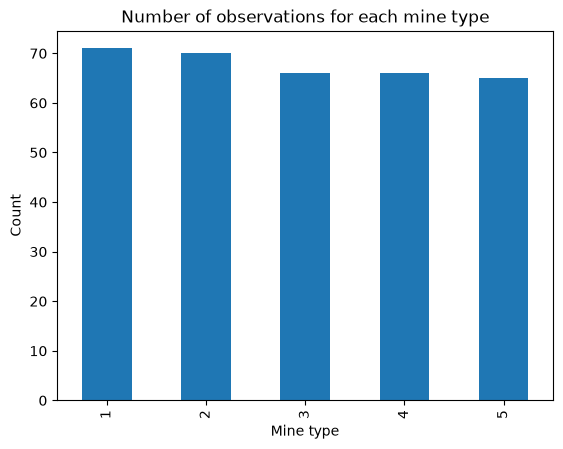

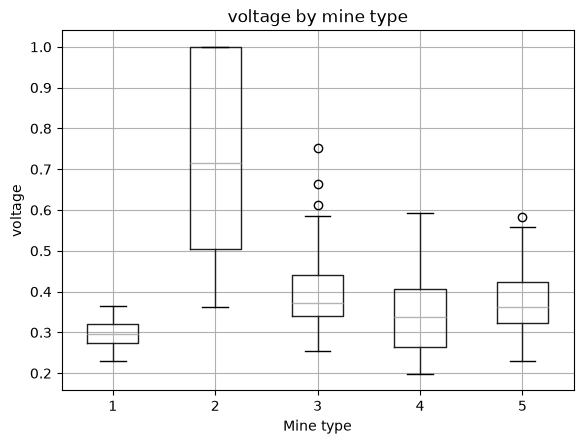

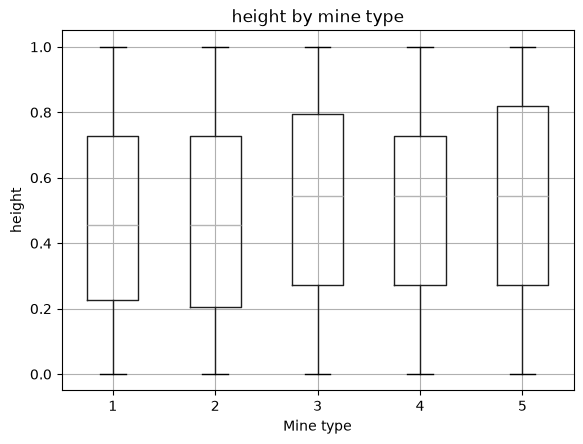

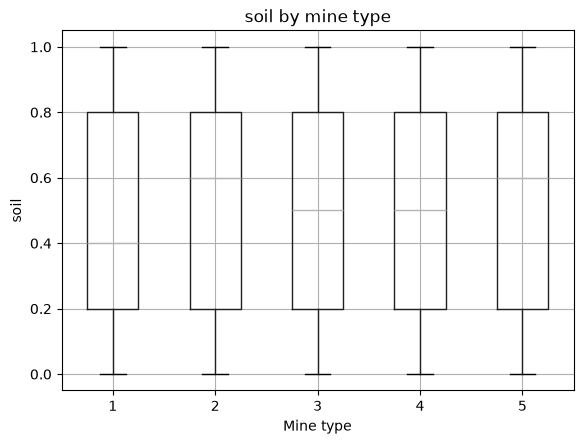


**EDA summary:** `mine_type` is a categorical target with five possible values. The class counts are fairly similar, so there is not a major class imbalance. `voltage`, `height`, and `soil` are the three predictors. The boxplots show that some feature distributions overlap across mine types, so the model will probably not classify every observation correctly.


Training observations: 169
Test observations: 169

Training class counts:
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64

Test class counts:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64

Accuracy for each k:


,k,accuracy
0,1,0.508876
1,2,0.473373
2,3,0.408284
3,4,0.414201
4,5,0.420118
5,6,0.414201
6,7,0.402367
7,8,0.414201
8,9,0.431953
9,10,0.431953


Best k: 1


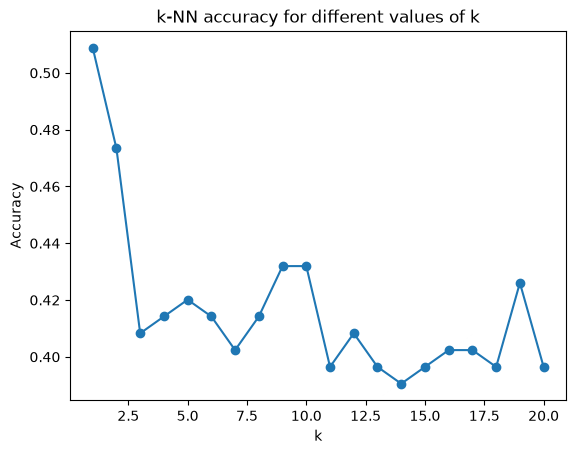


**How k was selected:** I tried values of `k` from 1 through 20 and compared their held-out accuracy. The value with the highest observed accuracy was `k = 1`. Small values of `k` can react strongly to individual observations, while larger values smooth across more neighbors. This is a simple first-pass tuning method; a stronger final workflow would use cross-validation on the training data rather than repeatedly using the final test data for model selection.


Test accuracy: 0.509

Confusion table:


,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5
Actual 1,22,0,3,3,8
Actual 2,0,32,0,3,0
Actual 3,7,0,10,9,7
Actual 4,6,5,4,13,5
Actual 5,6,0,10,7,9


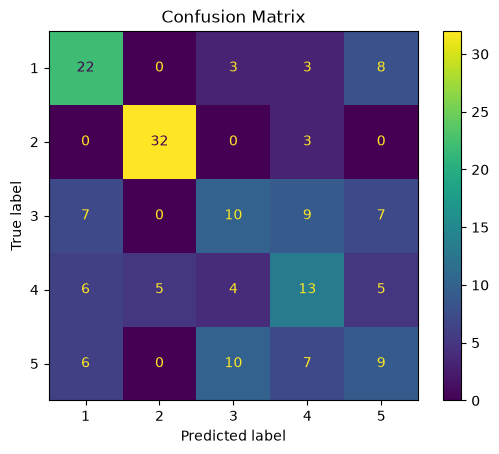


Class-by-class results:


,mine_type,correct,total,class_accuracy
0,1,22,36,0.611111
1,2,32,35,0.914286
2,3,10,33,0.303030
3,4,13,33,0.393939
4,5,9,32,0.281250



**Accuracy analysis:** The overall test accuracy is about **50.9%**. The confusion table is more informative than accuracy alone because it shows which mine types are being confused. In this split, mine type **2** has the highest proportion of correct predictions, while mine type **5** has the lowest. The off-diagonal entries show that some mine types are regularly mistaken for other classes.

**Practical advice:** I would not use this model by itself to make a final safety decision about a suspected land mine. It could be useful as an initial prediction or screening tool, especially for classes where the confusion table shows better performance. Predictions for mine types that the model frequently confuses should be verified using another method or by a trained expert before action is taken. Because the consequences of a wrong prediction could be serious, the pattern of errors in the confusion matrix matters as much as the overall accuracy.


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display, Markdown

# Q2.1 Load the data and perform basic EDA.
data_path = Path("data/land_mines.csv")
if not data_path.exists():
    data_path = Path("land_mines.csv")

df = pd.read_csv(data_path)

print("First five rows:")
display(df.head())

print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())

print("\nMine type counts:")
print(df["mine_type"].value_counts().sort_index())

print("\nFeature summary:")
print(df[["voltage", "height", "soil"]].describe())

# Simple look at the response variable.
df["mine_type"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Mine type")
plt.ylabel("Count")
plt.title("Number of observations for each mine type")
plt.show()

# Basic feature plots by class.
for feature in ["voltage", "height", "soil"]:
    df.boxplot(column=feature, by="mine_type")
    plt.title(f"{feature} by mine type")
    plt.suptitle("")
    plt.xlabel("Mine type")
    plt.ylabel(feature)
    plt.show()

eda_text = """
**EDA summary:** `mine_type` is a categorical target with five possible values. The class counts are fairly similar, so there is not a major class imbalance. `voltage`, `height`, and `soil` are the three predictors. The boxplots show that some feature distributions overlap across mine types, so the model will probably not classify every observation correctly.
"""
display(Markdown(eda_text))

# Q2.2 Split the sample 50/50.
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.50,
    random_state=42,
    stratify=y
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))
print("\nTraining class counts:")
print(y_train.value_counts().sort_index())
print("\nTest class counts:")
print(y_test.value_counts().sort_index())

# Q2.3 Build k-NN and select k.
# Standardization is used because k-NN is based on distances between observations.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, predictions))

results = pd.DataFrame({"k": list(k_values), "accuracy": accuracies})
print("\nAccuracy for each k:")
display(results)

best_k = int(results.loc[results["accuracy"].idxmax(), "k"])
print("Best k:", best_k)

plt.plot(results["k"], results["accuracy"], marker="o")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("k-NN accuracy for different values of k")
plt.show()

k_text = f"""
**How k was selected:** I tried values of `k` from 1 through 20 and compared their held-out accuracy. The value with the highest observed accuracy was `k = {best_k}`. Small values of `k` can react strongly to individual observations, while larger values smooth across more neighbors. This is a simple first-pass tuning method; a stronger final workflow would use cross-validation on the training data rather than repeatedly using the final test data for model selection.
"""
display(Markdown(k_text))

# Q2.4 Fit the selected model and print the confusion table.
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)
y_pred = final_model.predict(X_test_scaled)

final_accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", round(final_accuracy, 3))

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {x}" for x in labels],
    columns=[f"Predicted {x}" for x in labels]
)

print("\nConfusion table:")
display(cm_df)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot()
plt.title("Confusion Matrix")
plt.show()

# Simple class-by-class accuracy calculation.
class_results = []
for i, mine_type in enumerate(labels):
    total = cm[i, :].sum()
    correct = cm[i, i]
    class_results.append({
        "mine_type": mine_type,
        "correct": correct,
        "total": total,
        "class_accuracy": correct / total if total else 0
    })

class_results = pd.DataFrame(class_results)
print("\nClass-by-class results:")
display(class_results)

best_class = int(class_results.loc[class_results["class_accuracy"].idxmax(), "mine_type"])
worst_class = int(class_results.loc[class_results["class_accuracy"].idxmin(), "mine_type"])

analysis_text = f"""
**Accuracy analysis:** The overall test accuracy is about **{final_accuracy:.1%}**. The confusion table is more informative than accuracy alone because it shows which mine types are being confused. In this split, mine type **{best_class}** has the highest proportion of correct predictions, while mine type **{worst_class}** has the lowest. The off-diagonal entries show that some mine types are regularly mistaken for other classes.

**Practical advice:** I would not use this model by itself to make a final safety decision about a suspected land mine. It could be useful as an initial prediction or screening tool, especially for classes where the confusion table shows better performance. Predictions for mine types that the model frequently confuses should be verified using another method or by a trained expert before action is taken. Because the consequences of a wrong prediction could be serious, the pattern of errors in the confusion matrix matters as much as the overall accuracy.
"""
display(Markdown(analysis_text))


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 17663012507f0592ca3147f521d7bd8a1f93494b
- **AI tool and model used:** ChatGPT, GPT-5.6 Sol

### *Prompts used

1. Review my Phase 1 solution for the k-nearest-neighbor assignment. Identify specific conceptual, statistical, and coding improvements I could make without changing the original assignment requirements. Pay particular attention to how k is selected, whether the test set is being used appropriately, feature scaling, the confusion matrix, and the interpretation of model errors.

2. Based on those suggestions, provide an improved Phase 2 solution. Keep the required 50/50 train/test split, but use a stronger method for choosing k, explain the reasoning behind the changes, and give a more detailed interpretation of the model's class-specific errors and practical use for land-mine identification.

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Do not choose k by repeatedly evaluating models on the final test set. Instead, keep the 50% test set untouched and use cross-validation within the training set to choose k.

2. Keep feature standardization because k-NN is distance-based and variables on different scales can otherwise contribute unevenly to the distance calculation.

3. Make the explanation of the train/test split more precise by distinguishing between training, validation/model selection, and final testing. Repeatedly tuning a model based on test performance can make the reported test accuracy too optimistic.

4. Expand the confusion-matrix analysis beyond overall accuracy by calculating class-specific accuracy and identifying the classes that the model predicts most and least reliably.

5. Strengthen the practical recommendation by connecting it directly to the observed error patterns. Because this is a safety-critical land-mine application, the model should be treated as a screening or supporting tool rather than as the sole basis for a final decision.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | My Phase 1 code selected `k` by testing many values directly on the test set. I verified that this uses the test set during model selection, which can make the final accuracy estimate too optimistic. I changed Phase 2 to select `k` using cross-validation on the training data and use the test set only for final evaluation. |
| 2 | Accept | k-NN is based on distances between observations, so feature scale can affect which points are considered nearest neighbors. I kept feature standardization and verified that scaling is performed as part of the training process. |
| 3 | Accept | My Phase 1 explanation did not clearly separate model training, model selection, and final testing. I revised the explanation so that cross-validation is used for model selection while the final test set remains untouched until the selected model is evaluated. |
| 4 | Accept | Overall accuracy does not show how performance differs across mine types. I added class-specific accuracy and examined the confusion matrix to verify which classes are predicted more accurately and which classes are confused most often. |
| 5 | Accept | The model is being considered for a safety-critical land-mine application, so classification errors could have serious consequences. I revised the practical advice to recommend using the model as a screening or supporting tool and requiring additional verification before acting on its prediction. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

# Your Phase 2 solution to the problem goes here.


## Q1

**1. Regression and classification**

Regression predicts a numerical or continuous response, while classification predicts membership in a category or class. For example, predicting the exact voltage of an object would be a regression problem, while predicting whether an observation belongs to mine type 1, 2, 3, 4, or 5 is a classification problem.

**2. Confusion table**

A confusion table compares the actual class of each observation with the class predicted by a classification model. Correct predictions appear on the diagonal, while off-diagonal values represent mistakes. It is useful because it shows not only how many predictions are correct, but also which classes the model tends to confuse with each other.

**3. SSE**

SSE is the sum of squared errors:

\[
SSE = \sum_i (y_i-\hat{y}_i)^2
\]

It measures the total squared difference between observed values and model predictions. Smaller values generally indicate predictions that are closer to the observed values. Squaring the errors prevents positive and negative errors from canceling and gives larger errors more weight.

**4. Overfitting and underfitting**

Overfitting occurs when a model fits the training data too closely, including noise or patterns that do not generalize, so it performs much better on training data than on new data. Underfitting occurs when a model is too simple to capture important structure in the data, causing poor performance on both training and new observations.

For k-NN, a very small value of k can create a flexible model that may overfit, while a very large value of k can smooth the decision boundary too much and cause underfitting.

**5. Training/test splitting and choosing k**

Splitting the observations allows the model to be fit on one portion of the data and evaluated on observations that were not used to fit it. A held-out validation set can be used to compare different values of k, but repeatedly using the final test set to choose k would leak information from that test set into model selection and could make the reported performance too optimistic.

A stronger approach is to use cross-validation within the training data to select k and keep the final test set untouched until the model has been chosen. This preserves the purpose of the test set as an unbiased final evaluation of performance on unseen observations.

**6. Class labels versus class probabilities**

A class-label prediction gives one final predicted category. Its main strength is that it is simple and easy to interpret, but it does not communicate how uncertain the model is.

A probability distribution gives an estimated probability for every possible class. This provides more information because a user can distinguish between a highly confident prediction and an uncertain one. It can also support different decision thresholds when the consequences of errors are unequal. A weakness is that probability predictions are more complicated to interpret and the estimated probabilities may not be perfectly calibrated.

Shape: (338, 4)

Missing values:
voltage      0
height       0
soil         0
mine_type    0
dtype: int64

Mine type counts:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Feature summary:
          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000


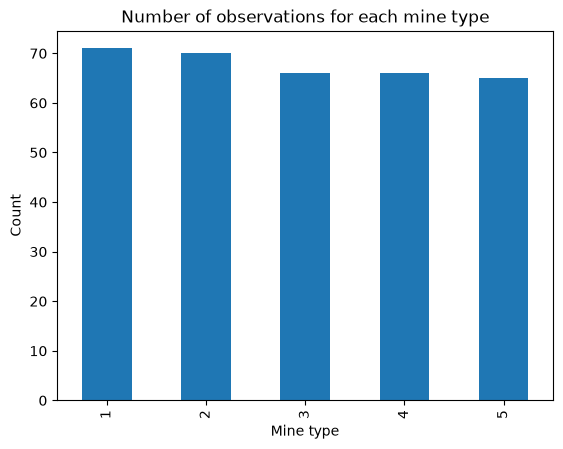

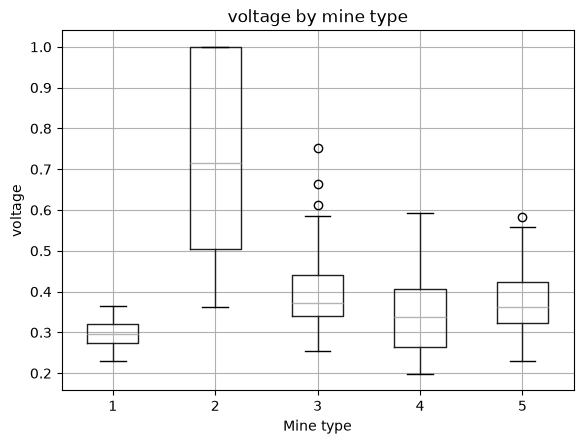

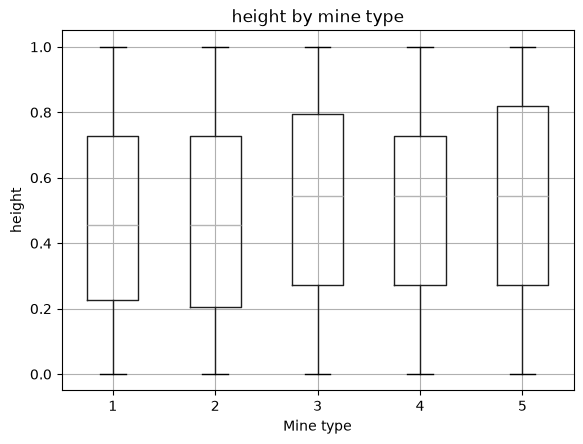

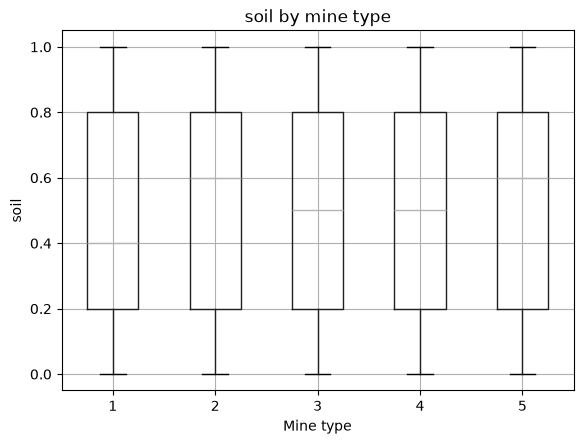


Training observations: 169
Test observations: 169

Cross-validation results:
     k  CV accuracy
0    1     0.468627
1    2     0.467380
2    3     0.479144
3    4     0.461497
4    5     0.485561
5    6     0.497504
6    7     0.444029
7    8     0.485561
8    9     0.468449
9   10     0.456328
10  11     0.444563
11  12     0.408734
12  13     0.432620
13  14     0.408913
14  15     0.355793
15  16     0.349911
16  17     0.373440
17  18     0.349554
18  19     0.361141
19  20     0.343850

Selected k: 6


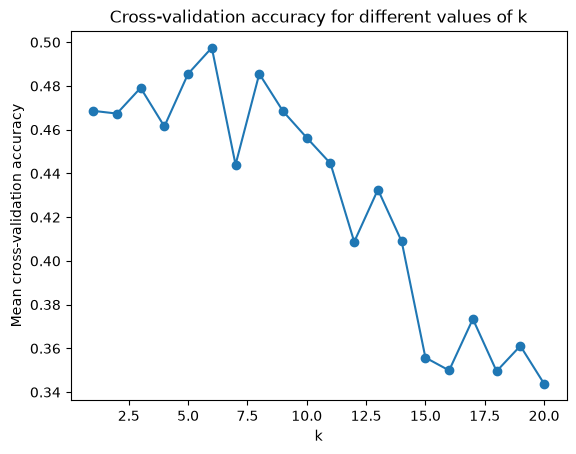


Final test accuracy: 0.414

Confusion table:
          Predicted 1  Predicted 2  Predicted 3  Predicted 4  Predicted 5
Actual 1           23            0            7            5            1
Actual 2            0           34            0            1            0
Actual 3            9            3            5            6           10
Actual 4           15            5            7            3            3
Actual 5            9            2           10            6            5


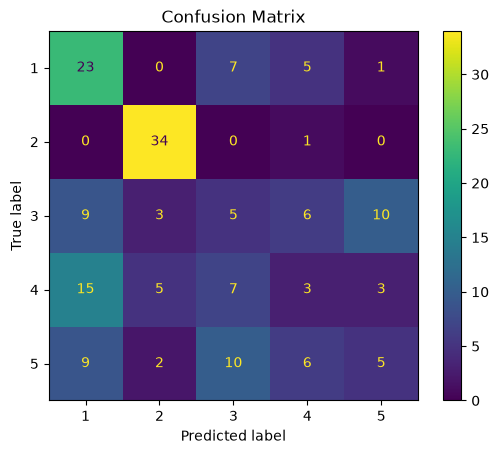


Class-specific performance:
   mine_type  correct  total  class_accuracy
0          1       23     36        0.638889
1          2       34     35        0.971429
2          3        5     33        0.151515
3          4        3     33        0.090909
4          5        5     32        0.156250

Highest class-specific accuracy: 2 0.971
Lowest class-specific accuracy: 4 0.091

Most common confusion: actual mine type 4 predicted as mine type 1 with 15 cases.


In [36]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load the data
df = pd.read_csv("data/land_mines.csv")

# -------------------------
# EDA
# -------------------------

print("Shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum())

print("\nMine type counts:")
print(df["mine_type"].value_counts().sort_index())

print("\nFeature summary:")
print(df[["voltage", "height", "soil"]].describe())

df["mine_type"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Mine type")
plt.ylabel("Count")
plt.title("Number of observations for each mine type")
plt.show()

for feature in ["voltage", "height", "soil"]:
    df.boxplot(column=feature, by="mine_type")
    plt.title(f"{feature} by mine type")
    plt.suptitle("")
    plt.xlabel("Mine type")
    plt.ylabel(feature)
    plt.show()

# -------------------------
# 50/50 train/test split
# -------------------------

X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.50,
    random_state=42,
    stratify=y
)

print("\nTraining observations:", len(X_train))
print("Test observations:", len(X_test))

# -------------------------
# Select k using cross-validation
# on training data only
# -------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

k_values = range(1, 21)
cv_scores = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    cv_scores.append(scores.mean())

results = pd.DataFrame({
    "k": list(k_values),
    "CV accuracy": cv_scores
})

print("\nCross-validation results:")
print(results)

best_k = int(
    results.loc[results["CV accuracy"].idxmax(), "k"]
)

print("\nSelected k:", best_k)

plt.plot(
    results["k"],
    results["CV accuracy"],
    marker="o"
)
plt.xlabel("k")
plt.ylabel("Mean cross-validation accuracy")
plt.title("Cross-validation accuracy for different values of k")
plt.show()

# -------------------------
# Fit final model
# -------------------------

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print("\nFinal test accuracy:", round(test_accuracy, 3))

# -------------------------
# Confusion matrix
# -------------------------

labels = sorted(y.unique())

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {x}" for x in labels],
    columns=[f"Predicted {x}" for x in labels]
)

print("\nConfusion table:")
print(cm_df)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
).plot()

plt.title("Confusion Matrix")
plt.show()

# -------------------------
# Class-specific accuracy
# -------------------------

class_results = []

for i, mine_type in enumerate(labels):
    total = cm[i].sum()
    correct = cm[i, i]

    class_results.append({
        "mine_type": mine_type,
        "correct": correct,
        "total": total,
        "class_accuracy": correct / total
    })

class_results = pd.DataFrame(class_results)

print("\nClass-specific performance:")
print(class_results)

best_class = class_results.loc[
    class_results["class_accuracy"].idxmax()
]

worst_class = class_results.loc[
    class_results["class_accuracy"].idxmin()
]

print(
    "\nHighest class-specific accuracy:",
    int(best_class["mine_type"]),
    round(best_class["class_accuracy"], 3)
)

print(
    "Lowest class-specific accuracy:",
    int(worst_class["mine_type"]),
    round(worst_class["class_accuracy"], 3)
)

# -------------------------
# Most common confusion
# -------------------------

cm_errors = cm.copy()

for i in range(len(labels)):
    cm_errors[i, i] = 0

row, col = divmod(
    cm_errors.argmax(),
    cm_errors.shape[1]
)

print(
    "\nMost common confusion:",
    f"actual mine type {labels[row]} predicted as mine type {labels[col]}",
    "with",
    cm_errors[row, col],
    "cases."
)

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

From phase 1 to phase two I saw a noticable difference in the way the value o f k was selceted. While in Phase 1 I compared the serval values of k directly on the test set and then chose the one with the highest accuracy. The AI corerctly pointed out that this uses info from the test set during model selection and can make the reported permorance look better than it really is. I accepted this insightful idea and changed the process. 

The AI however also suggested keeping feature standardization, and expanding the confusion matrix analysis and making the practical recommendation more specific to the error patterns. Although at first I was hesitant, I accepted those suggestions because they were consistent.I verified the final solution by running the notebook from top to bottom, checking that the 50/50 split was maintained, confirming that the cross-validation code selected a valid k, and reviewing the final accuracy and confusion matrix for consistency with the written interpretation.

A remaining limitation is that the model still makes a meaningful number of classification errors, so even the improved workflow does not make the classifier reliable enough to use by itself for decisions by itself